<a href="https://colab.research.google.com/github/Nutchayapon/Super_AI_Engineer-SS.6/blob/main/5D_Hackathon_House_Recognition_601661.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Super AI Engineer SS6] :  5 Domains Hackathon

#  House Recognition

In [ ]:
import os, csv, re, time, requests
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import userdata

In [ ]:
KAGGLE_API_KEY = userdata.get('KAGGLE_API')
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_KEY
!kaggle competitions download -c super-ai-engineer-season-6-individual-hackathon-house-recognition
!unzip -q super-ai-engineer-season-6-individual-hackathon-house-recognition

100% 1.25G/1.25G [00:18<00:00, 73.3MB/s]



In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 1. ลองเช็คว่าโฟลเดอร์ปัจจุบันมีไฟล์อะไรบ้าง
print("ไฟล์และโฟลเดอร์ในสารบบปัจจุบัน:", os.listdir())

# 2. โหลดไฟล์ train.csv (ถ้าชื่อไฟล์ต่างไป ให้แก้ตรงนี้นะครับ)
train_df = pd.read_csv('train.csv')

print("\n--- 5 แถวแรกของข้อมูล ---")
display(train_df.head())

print("\n--- ข้อมูลภาพรวม (มี Missing Value ไหม?) ---")
train_df.info()

/tmp/ipykernel_727/3346342885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='class', palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO 

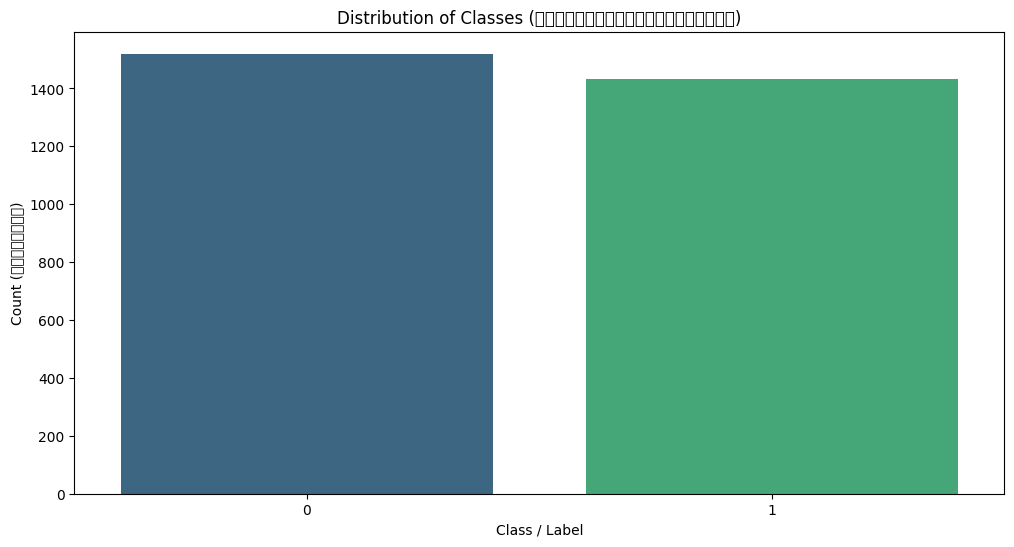


จำนวนรูปในแต่ละ Class:
class
0    1520
1    1433
Name: count, dtype: int64


In [ ]:
# สมมติว่าคอลัมน์ที่เป็นคำตอบชื่อ 'class' (ถ้าชื่ออื่นให้แก้ตรง x='...')
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='class', palette='viridis')
plt.title('Distribution of Classes (ความกระจายตัวของคลาส)')
plt.xlabel('Class / Label')
plt.ylabel('Count (จำนวนภาพ)')
plt.show()

print("\nจำนวนรูปในแต่ละ Class:")
print(train_df['class'].value_counts())

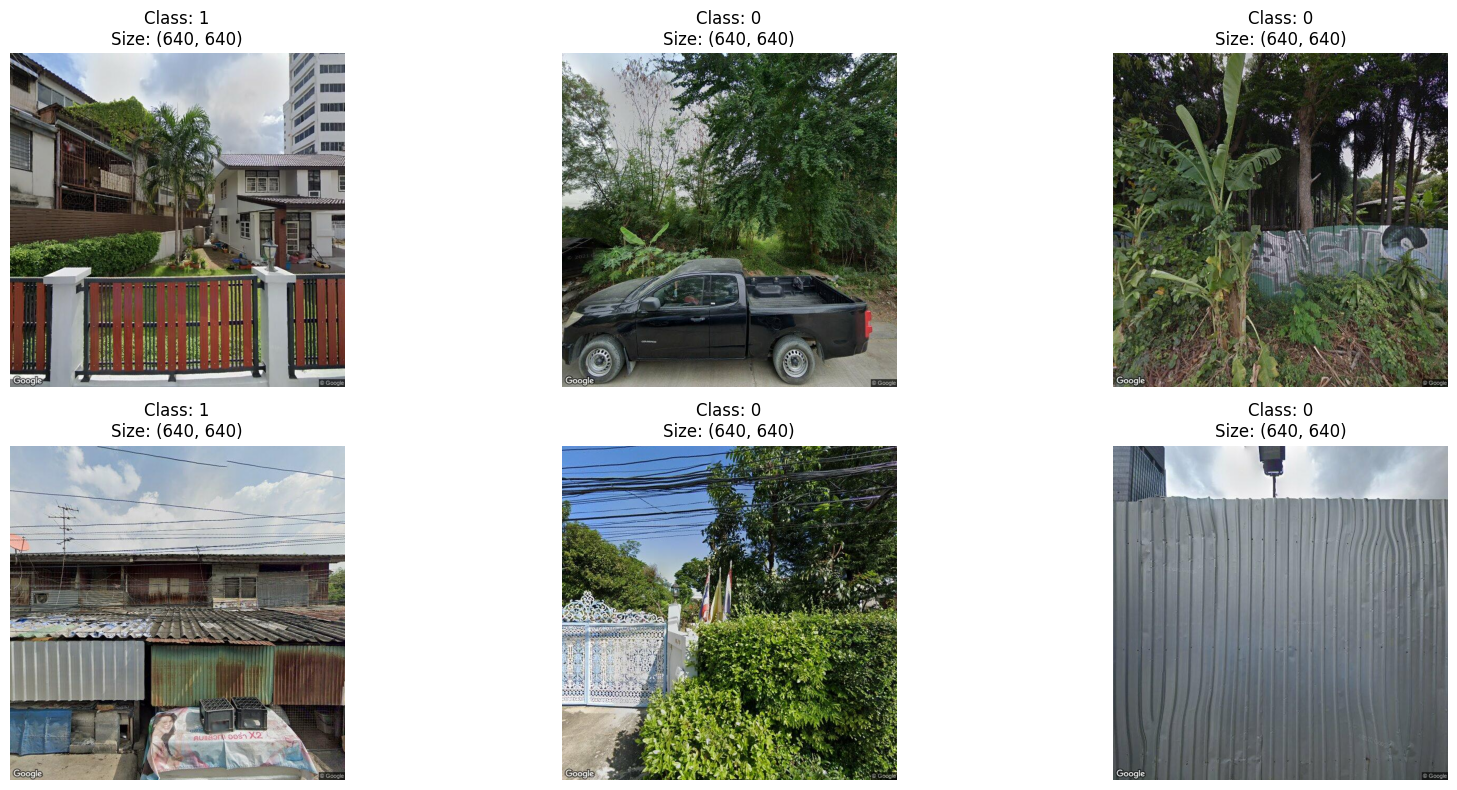

In [ ]:
# กำหนดชื่อโฟลเดอร์ที่เก็บรูปภาพ (ลองดูจากผลลัพธ์ os.listdir() ด้านบน)
IMAGE_DIR = 'train/train' # เพิ่ม /train เข้าไปอีกชั้น # เปลี่ยนชื่อโฟลเดอร์ตามจริงถ้าไม่ใช่ train

# สุ่มรูปมาดู 6 รูป
sample_df = train_df.sample(6, random_state=42)

plt.figure(figsize=(18, 8))
for i, (index, row) in enumerate(sample_df.iterrows()):
    # จัดการชื่อไฟล์ (เติม .jpg ถ้าไม่มี)
    img_name = str(row['image_name']).strip()
    if not img_name.lower().endswith('.jpg'):
        img_name += '.jpg'

    img_path = os.path.join(IMAGE_DIR, img_name)

    plt.subplot(2, 3, i+1)
    try:
        img = Image.open(img_path)
        plt.imshow(img)
        # แสดงคลาส และ ขนาดภาพ (Width x Height)
        plt.title(f"Class: {row['class']}\nSize: {img.size}")
        plt.axis('off')
    except FileNotFoundError:
        plt.text(0.5, 0.5, 'Image Not Found', ha='center', va='center')
        plt.title(f"Missing: {img_name}")
        plt.axis('off')

plt.tight_layout()
plt.show()

กำลังตรวจสอบขนาดรูปภาพ...


100%|██████████| 2953/2953 [00:00<00:00, 6217.82it/s]



--- สรุปขนาดรูปภาพทั้งหมด ---
image_size
640 x 640     2657
1920 x 925     296
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

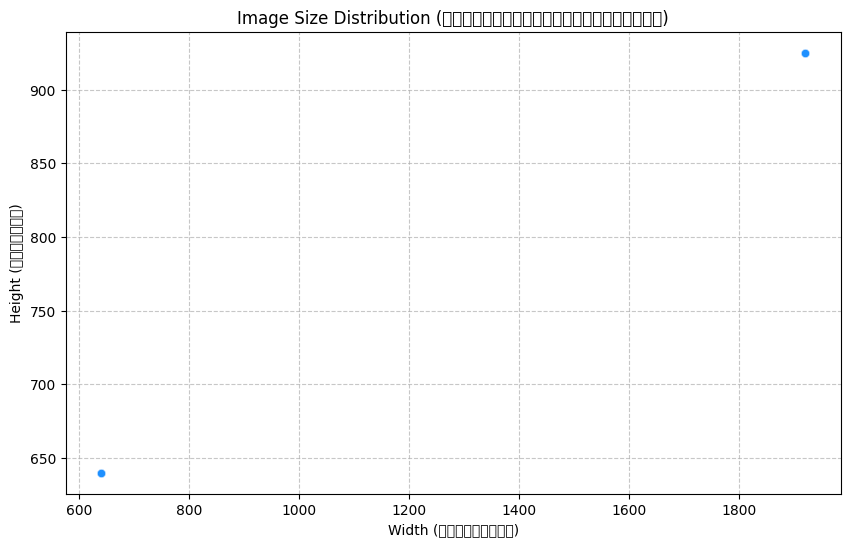

In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าโฟลเดอร์ให้ถูกต้องตามที่เราเช็คกันมา
IMAGE_DIR = 'train/train'
train_df = pd.read_csv('train.csv')

# ลิสต์สำหรับเก็บความกว้างและความสูง
widths = []
heights = []

print("กำลังตรวจสอบขนาดรูปภาพ...")
# วนลูปอ่านขนาดภาพทีละไฟล์
for img_name in tqdm(train_df['image_name']):
    img_name = str(img_name).strip()

    # เช็คนามสกุลไฟล์
    if not img_name.lower().endswith('.jpg'):
        img_name += '.jpg'

    img_path = os.path.join(IMAGE_DIR, img_name)

    try:
        # เปิดไฟล์ภาพเพื่อดึงขนาด (ใช้ with เพื่อปิดไฟล์อัตโนมัติ คืน Memory)
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except FileNotFoundError:
        # ถ้าหาไม่เจอจริงๆ ให้ใส่เป็นค่าว่างไว้ก่อน
        widths.append(None)
        heights.append(None)

# นำขนาดที่ได้กลับไปใส่ใน DataFrame
train_df['width'] = widths
train_df['height'] = heights

# ตัดแถวที่หาภาพไม่เจอออกไปก่อน (ถ้ามี)
valid_df = train_df.dropna(subset=['width', 'height']).copy()

# สร้างคอลัมน์ใหม่ที่รวม 'กว้าง x สูง' เพื่อดูง่ายๆ
valid_df['image_size'] = valid_df['width'].astype(int).astype(str) + ' x ' + valid_df['height'].astype(int).astype(str)

print("\n--- สรุปขนาดรูปภาพทั้งหมด ---")
size_counts = valid_df['image_size'].value_counts()
print(size_counts)

# พลอตกราฟจุด (Scatter Plot) ให้ดูภาพรวม
plt.figure(figsize=(10, 6))
sns.scatterplot(data=valid_df, x='width', y='height', alpha=0.6, color='dodgerblue')
plt.title('Image Size Distribution (การกระจายตัวของขนาดภาพ)')
plt.xlabel('Width (ความกว้าง)')
plt.ylabel('Height (ความสูง)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from torchvision import transforms

# 1. สำหรับตอน Train: เน้นให้โมเดลเห็นมุมมองที่หลากหลาย (Data Augmentation)
train_transforms = transforms.Compose([
    # แปลงเป็นจัตุรัสแบบยอมเบี้ยวเล็กน้อย เพื่อไม่ให้ขอบภาพ 1920 หายไป
    transforms.Resize((256, 256)),
    # สุ่มตัดภาพมา 224x224 เพื่อให้โมเดลทนทานต่อตำแหน่งของบ้าน
    transforms.RandomCrop(224),
    # สุ่มพลิกซ้ายขวา (บ้านหันซ้าย/ขวาก็ยังเป็นคลาสเดิม)
    transforms.RandomHorizontalFlip(),
    # สุ่มปรับแสงสีนิดหน่อยให้โมเดลเก่งขึ้น
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. สำหรับตอน Test / Validation: ไม่ต้องสุ่มอะไร เน้นความแม่นยำ
val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)), # บีบเป็นจัตุรัสเหมือนตอนเทรน
    transforms.CenterCrop(224),    # ตัดตรงกลางแบบเป๊ะๆ
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

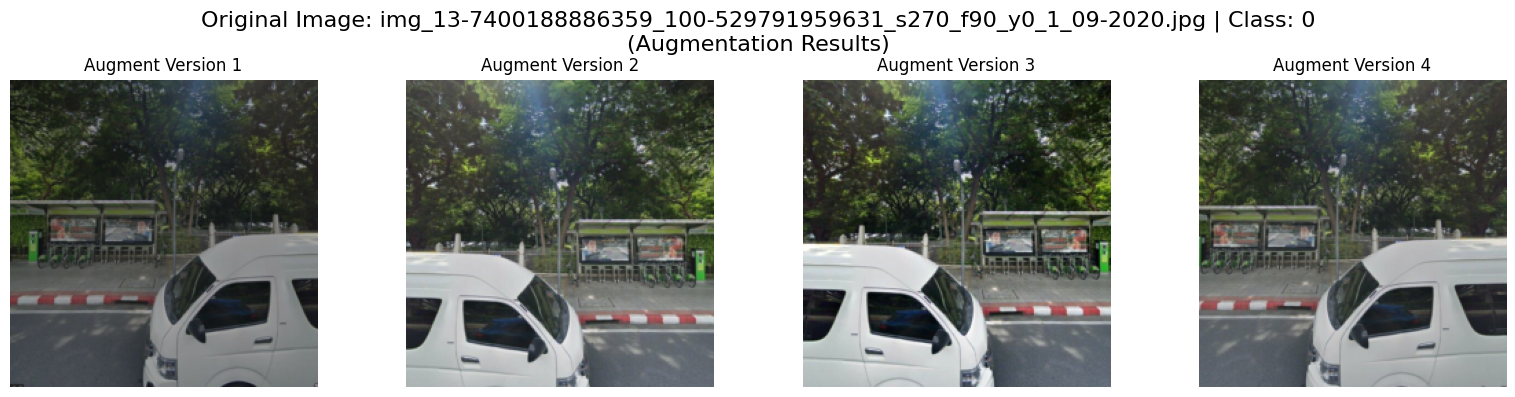

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from PIL import Image
from torch.utils.data import Dataset

# นิยาม HouseDataset (ป้องกัน NameError)
class HouseDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx]['image_name']).strip()
        if not img_name.lower().endswith('.jpg'): img_name += '.jpg'
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        label = self.df.iloc[idx]['class'] if 'class' in self.df.columns else -1
        if self.transform:
            image = self.transform(image)
        return image, label, img_name

# ฟังก์ชันสำหรับแปลง Tensor กลับเป็นรูปภาพปกติ
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# สร้าง Dataset ใหม่โดยใช้ train_transforms ที่นิยามไว้ก่อนหน้า
aug_dataset = HouseDataset(df=train_df, root_dir='train/train', transform=train_transforms)

sample_idx = 96
img_name = aug_dataset.df.iloc[sample_idx]['image_name']
label = aug_dataset.df.iloc[sample_idx]['class']

plt.figure(figsize=(16, 4))
plt.suptitle(f"Original Image: {img_name} | Class: {label}\n(Augmentation Results)", fontsize=16)

for i in range(4):
    augmented_img, _, _ = aug_dataset[sample_idx]
    plt.subplot(1, 4, i+1)
    imshow(augmented_img, title=f"Augment Version {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader, random_split
import torch

# แบ่ง train/val (80/20)
val_size = int(0.2 * len(train_df))
train_size = len(train_df) - val_size
train_subset, val_subset = random_split(
    range(len(train_df)), [train_size, val_size]
)

train_data = HouseDataset(
    train_df.iloc[list(train_subset)].reset_index(drop=True),
    root_dir='train/train',
    transform=train_transforms
)
val_data = HouseDataset(
    train_df.iloc[list(val_subset)].reset_index(drop=True),
    root_dir='train/train',
    transform=val_test_transforms
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, num_workers=2)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = train_df['class'].nunique()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ใช้ EfficientNet-B3 (เหมาะกับภาพบ้าน / ไม่หนักเกินไป)
model = models.efficientnet_b3(weights='IMAGENET1K_V1')

# แก้ classifier layer ให้ตรงกับจำนวน class ของเรา
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(device)

print(f"จำนวน class: {NUM_CLASSES}")
print(f"ใช้: {device}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 65.9MB/s]


จำนวน class: 2
ใช้: cpu


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            total_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # AUC: ถ้า multiclass ใช้ ovr
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc = float('nan')

    return total_loss / len(loader), correct / len(loader.dataset), auc

# =================== Training Loop ===================
history = {'epoch': [], 'train_loss': [], 'train_acc': [],
           'val_loss': [], 'val_acc': [], 'val_auc': []}
best_val_acc = 0

for epoch in range(20):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_auc = evaluate(model, val_loader, criterion)
    scheduler.step()

    # เก็บ history
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✅ Saved best model (val_acc={val_acc:.4f})")

# =================== Plot ===================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = history['epoch']

axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, history['train_acc'], label='Train Acc')
axes[1].plot(epochs, history['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs, history['val_auc'], label='Val AUC', color='green')
axes[2].set_title('Validation AUC per Epoch')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].legend(); axes[2].grid(True)

plt.suptitle(f'Training Summary | Best Val Acc: {best_val_acc:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# =================== Summary Table ===================
import pandas as pd
summary_df = pd.DataFrame(history)
summary_df['completed'] = '✅'
print(summary_df.to_string(index=False))
print(f"\nTotal epochs completed: {len(history['epoch'])}/20")
print(f"Best Val Acc: {best_val_acc:.4f}")

NameError: name 'model' is not defined

In [ ]:
import os
os.listdir()

In [ ]:
# เช็คว่าไฟล์แรกใน CSV มีอยู่จริงในโฟลเดอร์ไหม
import os
import pandas as pd

train_df = pd.read_csv('train.csv')
first_img = train_df.iloc[0]['image_name']
# ลองเช็คทั้งแบบมี .jpg และไม่มี
print(f"ชื่อใน CSV: {first_img}")
print(f"มีไฟล์นี้ในโฟลเดอร์ train ไหม?: {os.path.exists(os.path.join('train', first_img))}")
print(f"ถ้าเติม .jpg มีไหม?: {os.path.exists(os.path.join('train', first_img + '.jpg'))}")

# ลองดูชื่อไฟล์จริงๆ ในโฟลเดอร์สัก 3 ไฟล์
print(f"ไฟล์จริงๆ ในโฟลเดอร์ train: {os.listdir('train')[:3]}")

In [ ]:
import pandas as pd
import os

train_df = pd.read_csv('train.csv')
print(train_df.head())

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import os
from tqdm import tqdm

# --- 1. Custom Dataset ---
class HouseDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx]['image_name']).strip()
        img_path = os.path.join(self.root_dir, img_name)

        # จัดการเรื่องนามสกุลไฟล์
        if not os.path.exists(img_path) and not img_path.lower().endswith('.jpg'):
            img_path += '.jpg'

        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.df.iloc[idx]['class'], dtype=torch.float32) if 'class' in self.df.columns else torch.tensor(-1.0)

        if self.transform:
            image = self.transform(image)
        return image, label, img_name

# --- 2. Advanced Transforms ---
data_transforms = transforms.Compose([
    # 1. Resize ให้ด้านสั้นที่สุดเป็น 256 (รักษา Aspect Ratio)
    transforms.Resize(256),
    # 2. ตัดเฉพาะตรงกลาง 224x224 (โฟกัสบ้านตัวจริง)
    transforms.CenterCrop(224),
    # 3. ใส่ Padding ถ้าภาพเล็กเกินไป (กันเหนียว)
    transforms.Pad(padding=0, fill=0, padding_mode='constant'),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ฟังก์ชันสำหรับเปลี่ยน Tensor กลับเป็นรูปภาพที่คนมองเห็น (Unnormalize)
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # กลับค่า normalize
    img = np.clip(img, 0, 1) # ตัดค่าที่เกิน 0-1 ออก
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# สร้าง Dataset และ DataLoader สำหรับดูรูป
dataset_show = HouseDataset(df=train_df, root_dir='train', transform=data_transforms)
dataloader_show = DataLoader(dataset_show, batch_size=4, shuffle=True)

# ดึงภาพออกมา 1 batch
images, labels, names = next(iter(dataloader_show))

# แสดงผล 4 รูป
plt.figure(figsize=(15, 10))
for i in range(len(images)):
    plt.subplot(1, 4, i+1)
    imshow(images[i], title=f"Class: {int(labels[i])}\n{names[i]}")
plt.show()

In [ ]:
# --- 3. Model Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ใช้ ConvNeXt Tiny (เก่งกว่า MobileNet เยอะมาก)
model = models.convnext_tiny(weights='DEFAULT')
n_inputs = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Linear(n_inputs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 1)
)
model = model.to(device)

# โหลด Data (ใช้ path train/train ตามที่เราแก้กัน)
train_df = pd.read_csv('train.csv')
train_loader = DataLoader(HouseDataset(train_df, 'train/train', data_transforms),
                          batch_size=32, shuffle=True, num_workers=2)

# Optimizer & Scheduler ระดับสูง
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
# ค่อยๆ ลด LR เป็นเส้นโค้งเพื่อให้ลงจุดต่ำสุดได้แม่นยำ
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [ ]:
# --- 4. High-Accuracy Training ---
EPOCHS = 15
print(f"Training on {device}...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, labels, _ in loop:
        images, labels = images.to(device), labels.to(device).view(-1, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    scheduler.step() # อัปเดต Learning Rate
    print(f"Epoch {epoch+1} Done. Avg Loss: {total_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), 'convnext_house.pth')

In [ ]:
# --- 5. Inference with TTA ---
model.eval()
test_path = 'test/test' if os.path.exists('test/test') else 'test'
test_files = [f for f in os.listdir(test_path) if f.lower().endswith('.jpg')]
test_df_dummy = pd.DataFrame({'image_name': test_files})
test_loader = DataLoader(HouseDataset(test_df_dummy, test_path, data_transforms), batch_size=1)

results = []
with torch.no_grad():
    for images, _, img_names in tqdm(test_loader, desc="Predicting with TTA"):
        images = images.to(device)

        # 1. ทายรอบแรก (ปกติ)
        out1 = torch.sigmoid(model(images))

        # 2. ทายรอบสอง (กลับซ้ายขวา)
        out2 = torch.sigmoid(model(torch.flip(images, dims=[3])))

        # เฉลี่ยผลลัพธ์
        avg_prob = (out1 + out2) / 2
        pred = 1 if avg_prob.item() > 0.5 else 0

        results.append({'id': img_names[0].replace('.jpg', ''), 'answer': pred})

# สร้างไฟล์ Submission ตามลำดับที่ถูกต้อง
submission_df = pd.DataFrame(results)
sample_sub = pd.read_csv('sample_submission.csv')
final_sub = sample_sub[['id']].merge(submission_df, on='id', how='left')
final_sub['answer'] = final_sub['answer'].fillna(0).astype(int)

final_sub.to_csv('submission_final.csv', index=False)
print("Done! ส่งไฟล์ submission_final.csv ได้เลยครับ")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import os
import numpy as np
from tqdm import tqdm

# ============================================================
# CONFIG — แก้ตรงนี้ที่เดียว
# ============================================================
CFG = dict(
    batch_size   = 32,
    epochs       = 20,          # เพิ่มเป็น 20 แต่มี Early Stopping หยุดเองได้
    freeze_epochs= 3,           # Freeze backbone 3 epoch แรก (เร็วขึ้นมาก)
    lr_head      = 3e-4,        # LR สำหรับ head ช่วง freeze
    lr_full      = 5e-5,        # LR หลัง unfreeze (ต่ำกว่าเพื่อไม่ทำลาย pretrained)
    weight_decay = 1e-2,
    val_ratio    = 0.15,        # 15% สำหรับ validation
    patience     = 5,           # Early stopping: หยุดถ้า val ไม่ดีขึ้น 5 epoch
    img_size     = 224,
    num_workers  = 2,
    train_csv    = 'train.csv',
    train_img_dir= 'train/train',
    test_img_dir = 'test/test',
    save_path    = 'convnext_best.pth',
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"  # Mixed Precision เฉพาะ GPU

print(f"Device: {device} | AMP: {use_amp}")

# ============================================================
# 1. DATASET
# ============================================================
class HouseDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx]['image_name']).strip()
        img_path = os.path.join(self.root_dir, img_name)
        if not os.path.exists(img_path):
            img_path = img_path if img_path.lower().endswith('.jpg') else img_path + '.jpg'

        image = Image.open(img_path).convert("RGB")
        label = float(self.df.iloc[idx]['class']) if 'class' in self.df.columns else -1.0

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32), img_name

# ============================================================
# 2. TRANSFORMS  (Train มี Augmentation เพิ่ม / Val ไม่มี)
# ============================================================
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(CFG['img_size'], scale=(0.7, 1.0)),  # Crop แบบสุ่ม
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CFG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [ ]:
# ============================================================
# 3. SPLIT TRAIN / VAL
# ============================================================
df = pd.read_csv(CFG['train_csv'])
n_val = int(len(df) * CFG['val_ratio'])
n_train = len(df) - n_val

# Stratified split (รักษาสัดส่วน class)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=CFG['val_ratio'],
                                    stratify=df['class'], random_state=42)

train_ds = HouseDataset(train_df, CFG['train_img_dir'], train_tf)
val_ds   = HouseDataset(val_df,   CFG['train_img_dir'], val_tf)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# ============================================================
# 4. MODEL — ConvNeXt-Tiny + Custom Head
# ============================================================
model = models.convnext_tiny(weights='DEFAULT')
n_inputs = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Linear(n_inputs, 256),
    nn.GELU(),
    nn.Dropout(0.4),
    nn.Linear(256, 1)
)
model = model.to(device)

def freeze_backbone(m):
    for name, param in m.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False

def unfreeze_backbone(m):
    for param in m.parameters():
        param.requires_grad = True

In [ ]:
# ============================================================
# 5. TRAINING HELPERS
# ============================================================
criterion = nn.BCEWithLogitsLoss()
scaler    = torch.cuda.amp.GradScaler(enabled=use_amp)

def make_optimizer(lr):
    return optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=lr, weight_decay=CFG['weight_decay'])

def accuracy(logits, labels):
    preds = (torch.sigmoid(logits) > 0.5).float()
    return (preds == labels).float().mean().item()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_acc = 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device).view(-1, 1)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()
            total_acc  += accuracy(outputs.detach(), labels)

    n = len(loader)
    return total_loss / n, total_acc / n

# ============================================================
# 6. TRAINING LOOP  (Freeze → Unfreeze + Early Stop)
# ============================================================
best_val_acc = 0
patience_cnt = 0

# Phase 1: Freeze backbone — เทรนแค่ head ก่อน (เร็วมาก)
print("\n=== Phase 1: Freeze backbone ===")
freeze_backbone(model)
optimizer = make_optimizer(CFG['lr_head'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['freeze_epochs'])

for epoch in range(CFG['freeze_epochs']):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()
    print(f"[Freeze {epoch+1}/{CFG['freeze_epochs']}] "
          f"Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} | "
          f"Val Loss={va_loss:.4f} Acc={va_acc:.4f}")

# Phase 2: Unfreeze ทั้งหมด — Fine-tune
print("\n=== Phase 2: Full fine-tune ===")
unfreeze_backbone(model)
optimizer = make_optimizer(CFG['lr_full'])
remaining = CFG['epochs'] - CFG['freeze_epochs']
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

for epoch in range(remaining):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    improved = va_acc > best_val_acc
    tag = " ✓ BEST" if improved else ""
    print(f"[Full {epoch+1}/{remaining}] "
          f"Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} | "
          f"Val Loss={va_loss:.4f} Acc={va_acc:.4f}{tag}")

    if improved:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CFG['save_path'])
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= CFG['patience']:
            print(f"Early stopping! Best Val Acc = {best_val_acc:.4f}")
            break

# โหลด Best Model ก่อน Inference
model.load_state_dict(torch.load(CFG['save_path'], map_location=device))
print(f"\nLoaded best model (Val Acc = {best_val_acc:.4f})")

# ============================================================
# 7. INFERENCE + TTA (4 augmentations)
# ============================================================
tta_tfs = [
    val_tf,  # ปกติ
    transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                        transforms.RandomHorizontalFlip(p=1.0),  # flip แนวนอน
                        transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize(280), transforms.CenterCrop(224),  # zoom out
                        transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                        transforms.RandomRotation(degrees=(10,10)),  # หมุน 10 องศา
                        transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

test_path = CFG['test_img_dir'] if os.path.exists(CFG['test_img_dir']) else 'test'
test_files = [f for f in os.listdir(test_path) if f.lower().endswith('.jpg')]
test_df_dummy = pd.DataFrame({'image_name': test_files})

model.eval()
results = []

with torch.no_grad():
    for _, row in tqdm(test_df_dummy.iterrows(), total=len(test_df_dummy), desc="TTA Inference"):
        img_name = str(row['image_name']).strip()
        img_path = os.path.join(test_path, img_name)
        image_raw = Image.open(img_path).convert("RGB")

        probs = []
        for tf in tta_tfs:
            img_t = tf(image_raw).unsqueeze(0).to(device)
            with torch.cuda.amp.autocast(enabled=use_amp):
                prob = torch.sigmoid(model(img_t)).item()
            probs.append(prob)

        avg_prob = np.mean(probs)
        pred = 1 if avg_prob > 0.5 else 0
        results.append({'id': img_name.replace('.jpg', ''), 'answer': pred})

In [ ]:
# ============================================================
# 8. SUBMISSION
# ============================================================
submission_df = pd.DataFrame(results)
sample_sub = pd.read_csv('sample_submission.csv')
final_sub = sample_sub[['id']].merge(submission_df, on='id', how='left')
final_sub['answer'] = final_sub['answer'].fillna(0).astype(int)
final_sub.to_csv('submission_final_house.csv', index=False)

print(f"Best Val Accuracy: {best_val_acc:.4f}")